In [4]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path
import networkx as nx

import graph_delineator.delineate_reservoirs_update as gd

In [5]:
# Define MERIT data directories
merit_dirs = {
    'basins': Path('/nas/cee-ice/data/MERIT'),
    'flow_dir': Path('/nas/cee-ice/data/MERIT-Hydro/processed/dir/'),
    'flow_acc': Path('/nas/cee-ice/data/MERIT-Hydro/processed/upg/')
}
gauges_csv = Path('/work/pi_casey_umass_edu/Owen/Reservoirs/graph_delineator/demo/demo.csv')
output_dir = Path('/work/pi_casey_umass_edu/Owen/graph_delineator/Catchment_split_Outputs_working')

#Reservoirs GDB
gdb_path = '/work/pi_casey_umass_edu/Owen/Reservoirs/LakeSPvC_ts_for_Ted/SWOT_PLD_v106_reservoirs.gdb'

In [6]:
# 2. Load Reservoirs (Clipped)
print("Reading reservoirs based on gauge extent")
gauges_df = pd.read_csv(gauges_csv)
bbox = (
    gauges_df.lng.min() - 0.5, 
    gauges_df.lat.min() - 0.5, 
    gauges_df.lng.max() + 0.5, 
    gauges_df.lat.max() + 0.5
)


reservoirs = gpd.read_file(gdb_path, bbox=bbox)
print(f"Loaded {len(reservoirs)} reservoirs in the bounding box.")


Reading reservoirs based on gauge extent
Loaded 1398 reservoirs in the bounding box.


/work/pi_casey_umass_edu/Owen/graph_delineator/.venv/lib/python3.12/site-packages/pyogrio/raw.py:198: RuntimeWarning: organizePolygons() received a polygon with more than 100 parts. The processing may be really slow.  You can skip the processing by setting METHOD=SKIP, or only make it analyze counter-clock wise parts by setting METHOD=ONLY_CCW if you can assume that the outline of holes is counter-clock wise defined
  return ogr_read(


Filtered reservoirs by area >= 0.2 km2: 1398 -> 331

GRAPH-BASED WATERSHED DELINEATION
Data output directory: /work/pi_casey_umass_edu/Owen/graph_delineator/Catchment_split_Outputs_working
Loaded 128 gauges total.
Skipping 0 already processed outlets.
Processing 128 remaining gauges.


Basin 7:   0%|          | 0/1 [00:00<?, ?it/s]

  Reservoir 7310030152: merged 0 nodes into 7310030152
  Reservoir 7310031052: merged 0 nodes into 7310031052
  Reservoir 7310031422: merged 0 nodes into 7310031422
  Reservoir 7310031472: merged 0 nodes into 7310031472
  Reservoir 7310031793: merged 0 nodes into 7310031793
  Reservoir 7310031822: merged 0 nodes into 7310031822
  Reservoir 7310032282: merged 0 nodes into 7310032282
  Reservoir 7310032672: merged 0 nodes into 7310032672
  Reservoir 7310032772: merged 0 nodes into 7310032772
  Reservoir 7310033072: merged 0 nodes into 7310033072
  Reservoir 7310033722: merged 0 nodes into 7310033722
  Reservoir 7310034092: merged 0 nodes into 7310034092
  Reservoir 7310034162: merged 0 nodes into 7310034162
  Reservoir 7310034212: merged 0 nodes into 7310034212
  Reservoir 7310034532: merged 0 nodes into 7310034532
  Reservoir 7310034693: merged 0 nodes into 7310034693
  Reservoir 7310034712: merged 0 nodes into 7310034712
  Reservoir 7310034842: merged 0 nodes into 7310034842
  Reservoi

Basin 7: 100%|██████████| 1/1 [00:40<00:00, 40.74s/it]



DELINEATION SUMMARY
  Outlet USGS-01578310: 126 Gauges, 100 Reservoirs, 147 Catchment/Other Nodes
COMPLETE


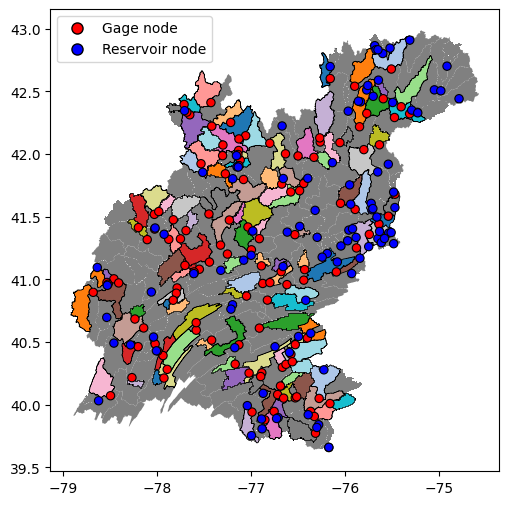

In [7]:
results = gd.delineate_basins(
        gauges_path=gauges_csv,
        merit_dirs=merit_dirs,
        reservoirs=reservoirs,
        min_reservoir_area_km2= 0.2,
        max_area=500,
        output_dir=output_dir,
        save_plots=True,
        consolidate=True,
        overwrite=True
)

In [8]:
# Run this AFTER results = delineate_basins(...)
G = results["USGS-01578310"].graph  # adjust outlet ID if different

for res_id in ["7310037603", "7310037662", "7310037522"]:
    if res_id not in G.nodes:
        print(f"{res_id}: NOT IN GRAPH")
        continue
    
    res_comid = G.nodes[res_id].get("original_comid")
    print(f"\n{'='*60}")
    print(f"Reservoir {res_id} — original_comid={res_comid}")
    print(f"  area={G.nodes[res_id].get('area_km2', 0):.1f} km²")
    
    # All nodes sharing the same COMID
    same_comid = [
        n for n in G.nodes
        if G.nodes[n].get("original_comid") == res_comid
    ]
    print(f"\n  All nodes with COMID {res_comid}:")
    for n in same_comid:
        d = G.nodes[n]
        preds = list(G.predecessors(n))
        succs = list(G.successors(n))
        print(f"    {n}: type={d.get('node_type')}, "
              f"area={d.get('area_km2',0):.1f} km², "
              f"is_gauge={d.get('is_gauge')}, is_res={d.get('is_reservoir')}, "
              f"preds={preds}, succs={succs}")



Reservoir 7310037603 — original_comid=73003648
  area=48.3 km²

  All nodes with COMID 73003648:
    7310037603: type=reservoir, area=48.3 km², is_gauge=False, is_res=True, preds=['73004571', '73003735'], succs=['USGS-01518700']

Reservoir 7310037662 — original_comid=73004571
  area=9.3 km²

  All nodes with COMID 73004571:
    73004571: type=split_downstream, area=32.9 km², is_gauge=False, is_res=None, preds=['7310037662'], succs=['7310037603']
    7310037662: type=reservoir, area=9.3 km², is_gauge=False, is_res=True, preds=[], succs=['73004571']

Reservoir 7310037522 — original_comid=73003440
  area=84.5 km²

  All nodes with COMID 73003440:
    USGS-01520000: type=split_downstream, area=4.3 km², is_gauge=True, is_res=None, preds=['7310037522'], succs=['USGS-01520500']
    7310037522: type=reservoir, area=84.5 km², is_gauge=False, is_res=True, preds=['73004679', '73003499'], succs=['USGS-01520000']
